# 🌍 WHO Global Health Data with ghoclient

This notebook demonstrates how to access World Health Organization (WHO) data using the ghoclient library.

**Data Source:** WHO Global Health Observatory (GHO)

**Available Data:**
- Disease burden (malaria, HIV/AIDS, tuberculosis)
- Mortality and life expectancy
- Health system indicators
- Risk factors (smoking, alcohol, obesity)
- Immunization coverage
- Environmental health

**Requirements:**
```bash
pip install ghoclient pandas matplotlib seaborn plotly
```

## 1. Setup and Imports

In [1]:
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

# ghoclient import
try:
    from ghoclient import GHO
    print("✅ ghoclient imported successfully!")
except ImportError:
    print("⚠️ ghoclient not installed. Installing...")
    import subprocess
    subprocess.run(['pip', 'install', 'ghoclient'])
    from ghoclient import GHO
    print("✅ ghoclient installed and imported!")

# Initialize client
gho = GHO()
print(f"⏰ Current time: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

✅ ghoclient imported successfully!
⏰ Current time: 2026-03-14 13:15


## 2. Exploring Available Indicators

In [2]:
# Get list of available indicators
print("📋 Fetching available WHO indicators...")

try:
    indicators = gho.get_indicators()
    print(f"✅ Found {len(indicators):,} indicators\n")

    # Display first few indicators
    print("🔍 Sample indicators:")
    for idx, row in indicators.head(10).iterrows():
        print(f"  • {row['IndicatorCode']}: {row['IndicatorName'][:60]}...")

except Exception as e:
    print(f"⚠️ Error fetching indicators: {e}")
    indicators = pd.DataFrame()

📋 Fetching available WHO indicators...
✅ Found 3,057 indicators

🔍 Sample indicators:
  • EMFLIMITELECTRICRF: Electric field (V/m)...
  • EMFLIMITMAGNETIC: Magnetic flux density (microT)...
  • EQ_CONDOMUSE: People who identify the use of condoms as a way to avoid AID...
  • FINPROTECTION_IMP_PG_190: Increase in poverty gap  due to household  health expenditur...
  • FINPROTECTION_IMP_PG_190_STD: Increase in poverty gap due to household  health expenditure...
  • FINPROTECTION_IMPOV_ESTIMATE_AVAILABLE: Availability of estimates on impoverishment due to out-of-po...
  • GDO_q10x1x1: Availability of generic anti-dementia medication...
  • GDO_q10x1x2: Availability of at least one anti-dementia medication approv...
  • HCF_NO_ELECTRICITY: Percentage of health-care facilities with no access to any e...
  • HIV_0000000006: Number of people dying from HIV-related causes...


In [3]:
# Search for specific indicators
if not indicators.empty:
    search_terms = ["malaria", "life expectancy", "immunization", "mortality"]

    print("🔎 Searching for health indicators:\n")
    for term in search_terms:
        matches = indicators[indicators['IndicatorName'].str.contains(term, case=False, na=False)]
        print(f"\n{term.upper()} ({len(matches)} matches):")
        for idx, row in matches.head(3).iterrows():
            print(f"  • {row['IndicatorCode']}: {row['IndicatorName'][:50]}...")

🔎 Searching for health indicators:


MALARIA (35 matches):
  • MALARIA002: Estimated number of malaria cases...
  • MALARIA003: Estimated number of malaria deaths...
  • MALARIA004: Number of under-five deaths from malaria...

LIFE EXPECTANCY (4 matches):
  • WHOSIS_000007: Healthy life expectancy (HALE) at age 60 (years)...
  • WHOSIS_000015: Life expectancy at age 60 (years)...
  • WHOSIS_000002: Healthy life expectancy (HALE) at birth (years)...

IMMUNIZATION (22 matches):
  • fullv: Full immunization coverage among one-year-olds (%)...
  • mslv: Measles immunization coverage among one-year-olds ...
  • bcgv: BCG immunization coverage among one-year-olds (%)...

MORTALITY (32 matches):
  • MORTADO: Adolescent mortality rate (per 1 000 age specific ...
  • imr: Infant mortality rate (deaths per 1000 live births...
  • CHILDMORT5TO14: Mortality rate for 5-14 year-olds (probability of ...


## 3. Tuberculosis Data Analysis

In [4]:
# Get tuberculosis incidence data
print("📥 Downloading tuberculosis incidence data...")

# TB incidence indicator (per 100,000 population)
tb_indicator_code = "MDG_0000000020"

# Select countries for comparison
countries = {
    "BRA": "Brazil",
    "IND": "India",
    "NGA": "Nigeria",
    "COD": "DRC",
    "UGA": "Uganda",
    "KEN": "Kenya"
}

try:
    # Get TB incidence
    malaria_data = gho.get_data(tb_indicator_code, countries=list(countries.keys()))

    print(f"✅ Downloaded {len(malaria_data)} records")
    print("\n📊 Data preview:")
    display(malaria_data.head())

except Exception as e:
    print(f"⚠️ Error downloading TB data: {e}")
    malaria_data = pd.DataFrame()

📥 Downloading tuberculosis incidence data...
✅ Downloaded 150 records

📊 Data preview:


,Id,IndicatorCode,SpatialDimType,SpatialDim,TimeDimType,ParentLocationCode,ParentLocation,Dim1Type,Dim1,TimeDim,...,DataSourceDim,Value,NumericValue,Low,High,Comments,Date,TimeDimensionValue,TimeDimensionBegin,TimeDimensionEnd
0,7365047,MDG_0000000020,COUNTRY,UGA,YEAR,AFR,Africa,None,None,2004,...,None,240 [156-341],240.0,156.0,341.0,None,2025-11-11T15:08:09.963+01:00,2004,2004-01-01T00:00:00+01:00,2004-12-31T00:00:00+01:00
1,7401398,MDG_0000000020,COUNTRY,IND,YEAR,SEAR,South-East Asia,None,None,2015,...,None,237 [181-300],237.0,181.0,300.0,None,2025-11-11T15:08:09.963+01:00,2015,2015-01-01T00:00:00+01:00,2015-12-31T00:00:00+01:00
2,7421157,MDG_0000000020,COUNTRY,IND,YEAR,SEAR,South-East Asia,None,None,2009,...,None,283 [113-530],283.0,113.0,530.0,None,2025-11-11T15:08:09.963+01:00,2009,2009-01-01T00:00:00+01:00,2009-12-31T00:00:00+01:00
3,7455197,MDG_0000000020,COUNTRY,COD,YEAR,AFR,Africa,None,None,2010,...,None,500 [306-961],500.0,306.0,961.0,None,2025-11-11T15:08:09.963+01:00,2010,2010-01-01T00:00:00+01:00,2010-12-31T00:00:00+01:00
4,7482781,MDG_0000000020,COUNTRY,BRA,YEAR,AMR,Americas,None,None,2021,...,None,47 [38-56],47.0,38.0,56.0,None,2025-11-11T15:08:09.963+01:00,2021,2021-01-01T00:00:00+01:00,2021-12-31T00:00:00+01:00


📈 Tuberculosis Incidence Analysis:

  Brazil (BRA):
    Latest year: 2024
    Incidence: 49.00 per 100,000
    Trend: -6.00 change since 2015

  India (IND):
    Latest year: 2024
    Incidence: 187.00 per 100,000
    Trend: -45.00 change since 2015

  Nigeria (NGA):
    Latest year: 2024
    Incidence: 219.00 per 100,000
    Trend: 0.00 change since 2015

  DRC (COD):
    Latest year: 2024
    Incidence: 377.00 per 100,000
    Trend: -32.00 change since 2015

  Uganda (UGA):
    Latest year: 2024
    Incidence: 197.00 per 100,000
    Trend: 3.00 change since 2015

  Kenya (KEN):
    Latest year: 2024
    Incidence: 207.00 per 100,000
    Trend: -141.00 change since 2015



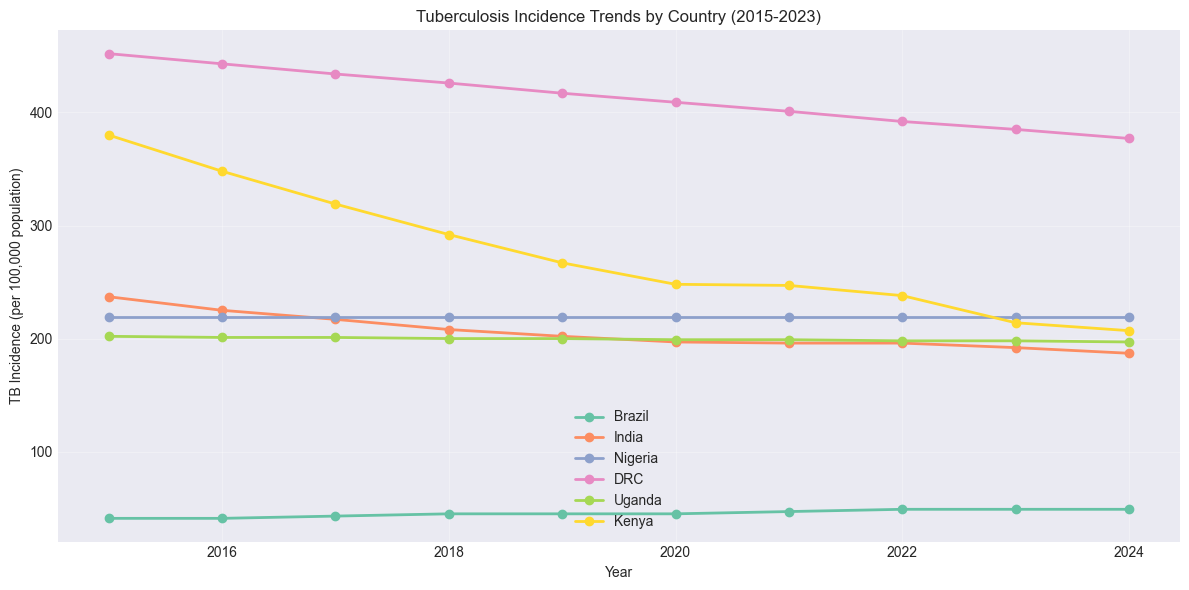

In [5]:
# Process and visualize TB data
if not malaria_data.empty:
    # Convert numeric columns
    malaria_data['NumericValue'] = pd.to_numeric(malaria_data['NumericValue'], errors='coerce')
    malaria_data['TimeDim'] = pd.to_numeric(malaria_data['TimeDim'], errors='coerce')

    # Filter recent years
    recent_data = malaria_data[malaria_data['TimeDim'] >= 2015]

    print("📈 Tuberculosis Incidence Analysis:\n")

    # Summary by country
    for code, name in countries.items():
        country_data = recent_data[recent_data['SpatialDim'] == code]
        if not country_data.empty:
            latest = country_data.loc[country_data['TimeDim'].idxmax()]
            print(f"  {name} ({code}):")
            print(f"    Latest year: {int(latest['TimeDim'])}")
            print(f"    Incidence: {latest['NumericValue']:.2f} per 100,000")
            print(f"    Trend: {country_data['NumericValue'].iloc[-1] - country_data['NumericValue'].iloc[0]:.2f} change since 2015")
            print()

    # Visualization
    fig, ax = plt.subplots(figsize=(12, 6))

    for code, name in countries.items():
        country_data = recent_data[recent_data['SpatialDim'] == code].sort_values('TimeDim')
        if len(country_data) > 0:
            ax.plot(country_data['TimeDim'], country_data['NumericValue'],
                   marker='o', linewidth=2, label=name)

    ax.set_xlabel('Year')
    ax.set_ylabel('TB Incidence (per 100,000 population)')
    ax.set_title('Tuberculosis Incidence Trends by Country (2015-2023)')
    ax.legend(loc='best', framealpha=0.9)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## 4. Life Expectancy Analysis

In [6]:
# Get life expectancy data
print("📥 Downloading life expectancy data...")

# Life expectancy at birth indicator
life_exp_countries = ["BRA", "USA", "CHN", "IND", "NGA", "JPN", "DEU", "FRA"]

try:
    life_exp_data = gho.get_data("WHOSIS_000001", countries=life_exp_countries)

    print(f"✅ Downloaded {len(life_exp_data)} records")

    # Process data
    life_exp_data['NumericValue'] = pd.to_numeric(life_exp_data['NumericValue'], errors='coerce')
    life_exp_data['TimeDim'] = pd.to_numeric(life_exp_data['TimeDim'], errors='coerce')

    # Get latest year for each country
    latest_data = life_exp_data.loc[life_exp_data.groupby('SpatialDim')['TimeDim'].idxmax()]

    print("\n🌍 Life Expectancy at Birth (Latest Available Year):")
    for _, row in latest_data.sort_values('NumericValue', ascending=False).iterrows():
        print(f"  {row['SpatialDim']}: {row['NumericValue']:.1f} years ({int(row['TimeDim'])})")

except Exception as e:
    print(f"⚠️ Error downloading life expectancy data: {e}")
    life_exp_data = pd.DataFrame()

📥 Downloading life expectancy data...
✅ Downloaded 528 records

🌍 Life Expectancy at Birth (Latest Available Year):
  FRA: 84.7 years (2021)
  DEU: 82.9 years (2021)
  JPN: 81.7 years (2021)
  CHN: 80.5 years (2021)
  USA: 76.4 years (2021)
  BRA: 69.0 years (2021)
  IND: 67.3 years (2021)
  NGA: 64.8 years (2021)


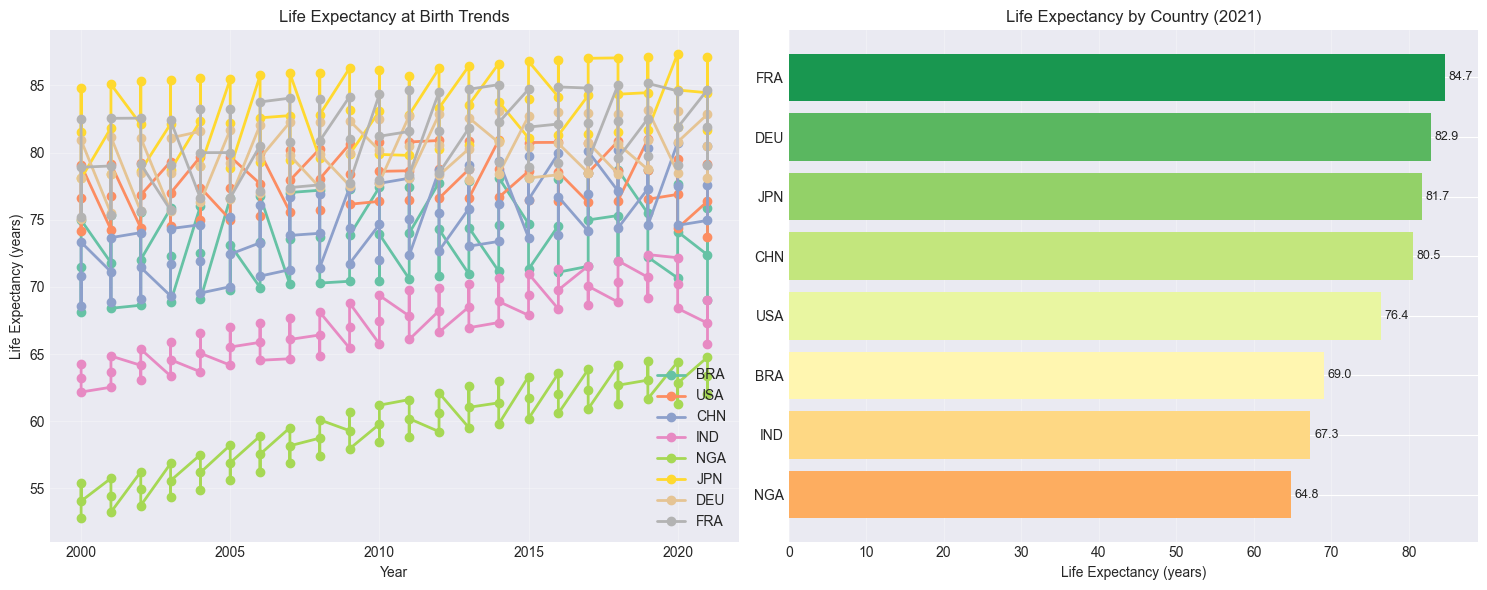

In [7]:
# Visualize life expectancy
if not life_exp_data.empty:
    # Time series
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Plot 1: Time series
    for country in life_exp_countries:
        country_data = life_exp_data[life_exp_data['SpatialDim'] == country].sort_values('TimeDim')
        if len(country_data) > 0:
            axes[0].plot(country_data['TimeDim'], country_data['NumericValue'],
                        marker='o', linewidth=2, label=country)

    axes[0].set_xlabel('Year')
    axes[0].set_ylabel('Life Expectancy (years)')
    axes[0].set_title('Life Expectancy at Birth Trends')
    axes[0].legend(loc='best')
    axes[0].grid(True, alpha=0.3)

    # Plot 2: Bar chart of latest values
    if not latest_data.empty:
        latest_sorted = latest_data.sort_values('NumericValue', ascending=True)
        colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(latest_sorted)))

        bars = axes[1].barh(latest_sorted['SpatialDim'], latest_sorted['NumericValue'], color=colors)
        axes[1].set_xlabel('Life Expectancy (years)')
        axes[1].set_title(f'Life Expectancy by Country ({int(latest_sorted['TimeDim'].iloc[0])})')
        axes[1].grid(True, alpha=0.3, axis='x')

        # Add value labels
        for i, (idx, row) in enumerate(latest_sorted.iterrows()):
            axes[1].text(row['NumericValue'] + 0.5, i, f"{row['NumericValue']:.1f}",
                        va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

## 5. Immunization Coverage

In [8]:
# Get immunization data
print("📥 Downloading immunization coverage data...")

# DTP3 (3rd dose of Diphtheria, Tetanus, Pertussis) immunization
immun_countries = ["BRA", "USA", "CHN", "IND", "NGA", "PAK", "IDN", "ETH"]

try:
    dtp3_data = gho.get_data("WHS4_100", countries=immun_countries)

    print(f"✅ Downloaded {len(dtp3_data)} records")

    # Process data
    dtp3_data['NumericValue'] = pd.to_numeric(dtp3_data['NumericValue'], errors='coerce')
    dtp3_data['TimeDim'] = pd.to_numeric(dtp3_data['TimeDim'], errors='coerce')

    # Filter recent years
    recent_dtp3 = dtp3_data[dtp3_data['TimeDim'] >= 2015]

    print("\n💉 DTP3 Immunization Coverage (% of target population):")
    for country in immun_countries:
        country_data = recent_dtp3[recent_dtp3['SpatialDim'] == country]
        if not country_data.empty:
            latest = country_data.loc[country_data['TimeDim'].idxmax()]
            print(f"  {country}: {latest['NumericValue']:.1f}% ({int(latest['TimeDim'])})")

except Exception as e:
    print(f"⚠️ Error downloading immunization data: {e}")
    dtp3_data = pd.DataFrame()

📥 Downloading immunization coverage data...
✅ Downloaded 200 records

💉 DTP3 Immunization Coverage (% of target population):
  BRA: 91.0% (2024)
  USA: 94.0% (2024)
  CHN: 97.0% (2024)
  IND: 94.0% (2024)
  NGA: 67.0% (2024)
  PAK: 87.0% (2024)
  IDN: 78.0% (2024)
  ETH: 73.0% (2024)


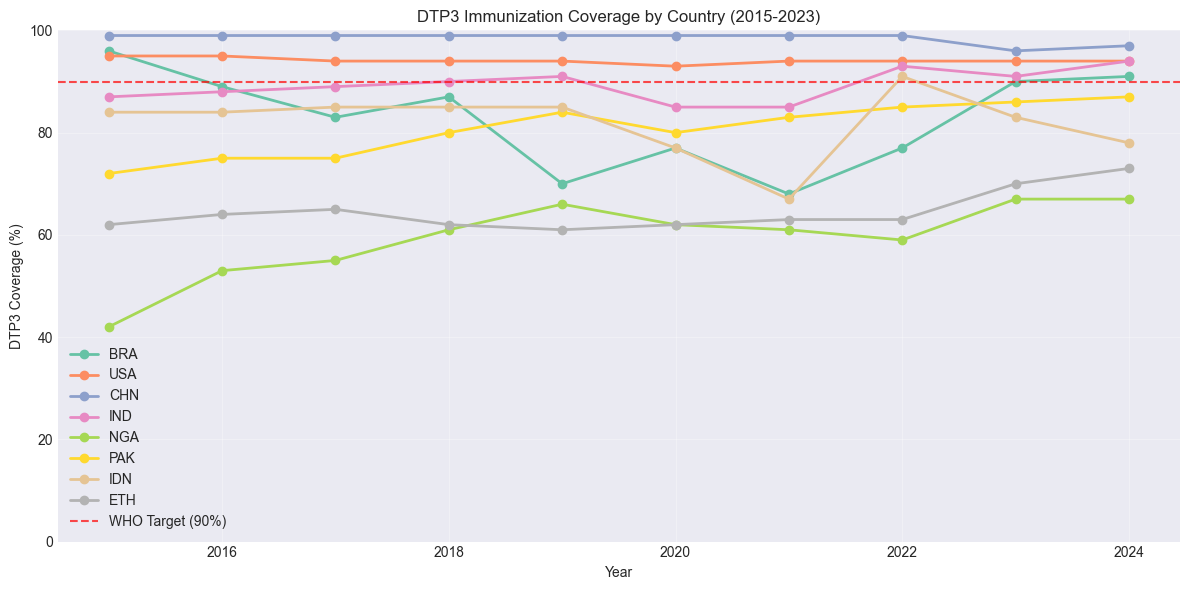


⚠️ Countries below WHO 90% target: 4/8
  • ETH: 73.0%
  • IDN: 78.0%
  • NGA: 67.0%
  • PAK: 87.0%


In [9]:
# Visualize immunization coverage
if not dtp3_data.empty and not recent_dtp3.empty:
    fig, ax = plt.subplots(figsize=(12, 6))

    for country in immun_countries:
        country_data = recent_dtp3[recent_dtp3['SpatialDim'] == country].sort_values('TimeDim')
        if len(country_data) > 0:
            ax.plot(country_data['TimeDim'], country_data['NumericValue'],
                   marker='o', linewidth=2, label=country)

    # Add 90% target line
    ax.axhline(y=90, color='red', linestyle='--', alpha=0.7, label='WHO Target (90%)')

    ax.set_xlabel('Year')
    ax.set_ylabel('DTP3 Coverage (%)')
    ax.set_title('DTP3 Immunization Coverage by Country (2015-2023)')
    ax.legend(loc='best', framealpha=0.9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 100)

    plt.tight_layout()
    plt.show()

    # Calculate countries below target
    latest_immun = recent_dtp3.loc[recent_dtp3.groupby('SpatialDim')['TimeDim'].idxmax()]
    below_target = latest_immun[latest_immun['NumericValue'] < 90]

    print(f"\n⚠️ Countries below WHO 90% target: {len(below_target)}/{len(latest_immun)}")
    for _, row in below_target.iterrows():
        print(f"  • {row['SpatialDim']}: {row['NumericValue']:.1f}%")

## 6. Comparative Health Indicators Dashboard

In [10]:
# Create a comparative dashboard
print("📊 Creating comparative health dashboard...")

dashboard_countries = ["BRA", "USA", "CHN", "IND", "NGA", "JPN"]

# Collect multiple indicators
indicators_to_fetch = {
    "Life Expectancy": "WHOSIS_000001",
    "Under-5 Mortality": "MDG_0000000007",
    "Maternal Mortality": "MDG_0000000026",
    "Physicians (per 1000)": "HRH_1"
}

dashboard_data = {}

for name, code in indicators_to_fetch.items():
    try:
        data = gho.get_data(code, countries=dashboard_countries)
        if not data.empty:
            data['NumericValue'] = pd.to_numeric(data['NumericValue'], errors='coerce')
            data['TimeDim'] = pd.to_numeric(data['TimeDim'], errors='coerce')
            # Get latest for each country
            latest = data.loc[data.groupby('SpatialDim')['TimeDim'].idxmax()]
            dashboard_data[name] = latest.set_index('SpatialDim')['NumericValue']
            print(f"✅ {name}: {len(latest)} countries")
    except Exception as e:
        print(f"⚠️ {name}: {e}")

# Create comparison DataFrame
if dashboard_data:
    comparison_df = pd.DataFrame(dashboard_data)
    print("\n📋 Health Indicators Comparison:")
    display(comparison_df.round(2))

📊 Creating comparative health dashboard...
✅ Life Expectancy: 6 countries
✅ Under-5 Mortality: 6 countries
✅ Maternal Mortality: 6 countries
⚠️ Physicians (per 1000): 404 Client Error: Not Found for url: https://ghoapi.azureedge.net/api/HRH_1?$filter=(SpatialDim%20eq%20'BRA'%20or%20SpatialDim%20eq%20'USA'%20or%20SpatialDim%20eq%20'CHN'%20or%20SpatialDim%20eq%20'IND'%20or%20SpatialDim%20eq%20'NGA'%20or%20SpatialDim%20eq%20'JPN')

📋 Health Indicators Comparison:


,Life Expectancy,Under-5 Mortality,Maternal Mortality
SpatialDim,,,
BRA,69.04,11.98,66.91
CHN,80.52,5.86,16.25
IND,67.31,42.22,80.48
JPN,81.71,2.47,3.08
NGA,64.78,84.46,992.83
USA,76.37,5.91,16.63


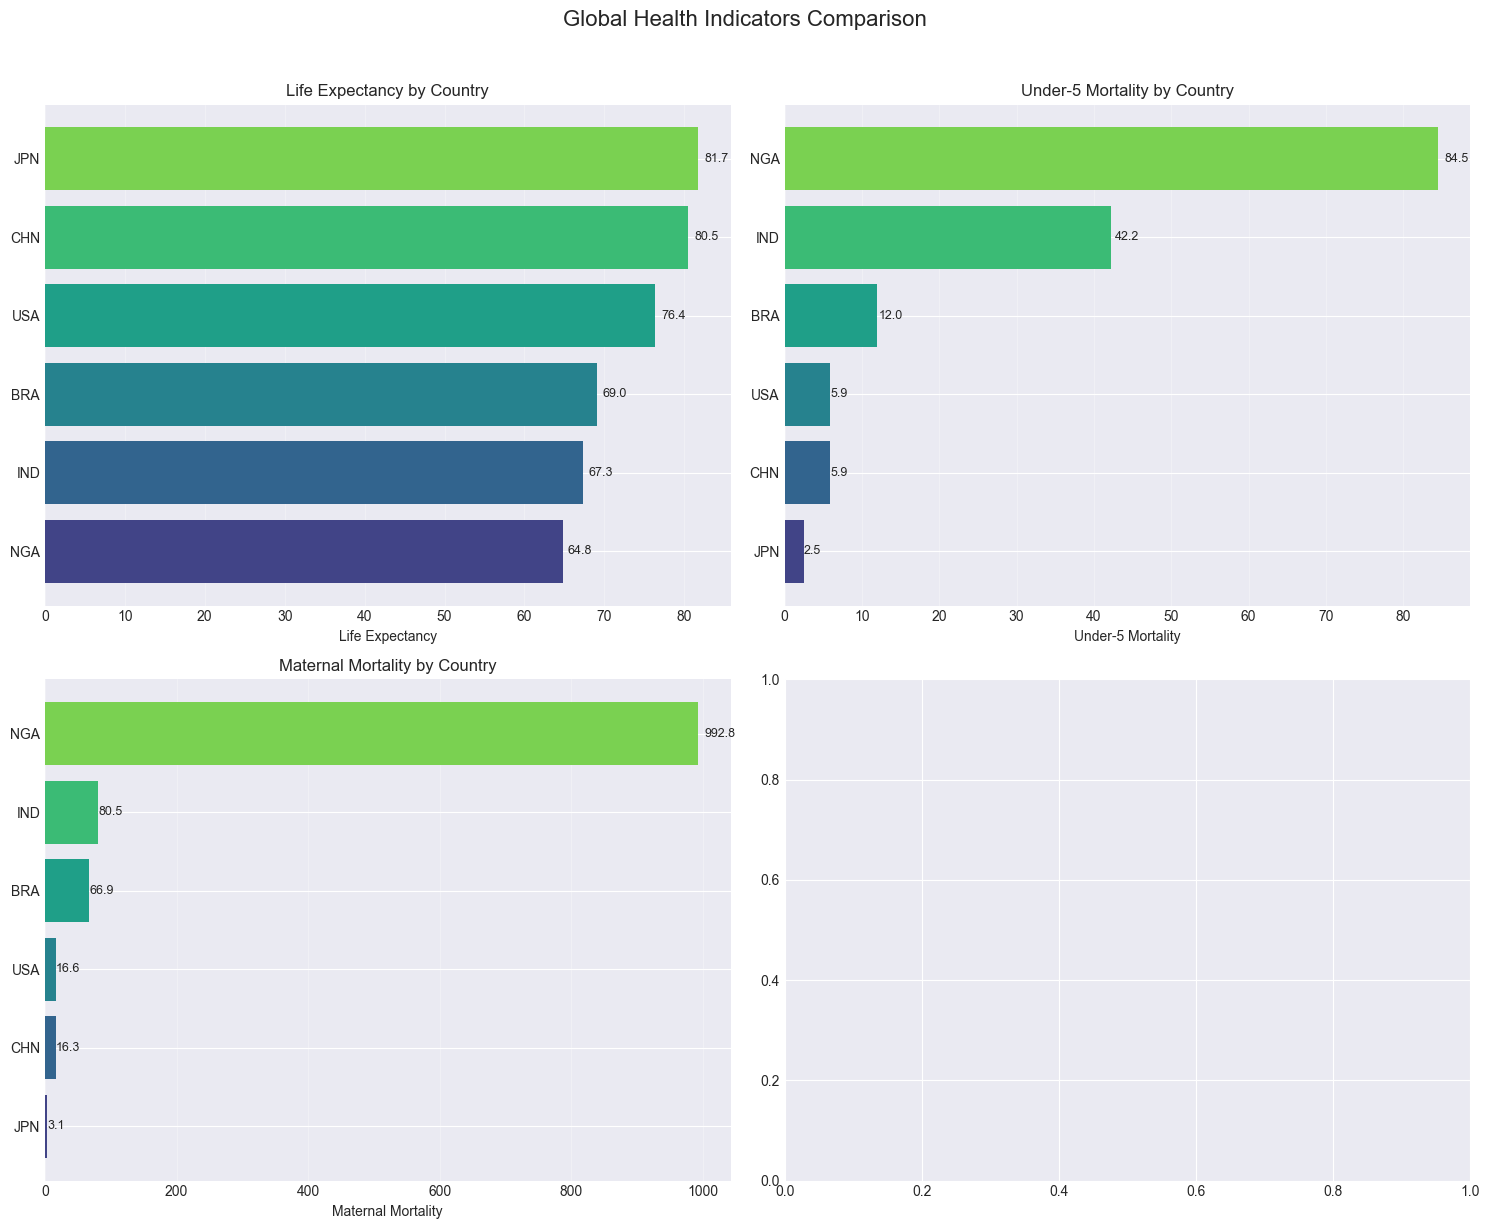

In [11]:
# Visualize dashboard
if 'comparison_df' in locals() and not comparison_df.empty:
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()

    for i, col in enumerate(comparison_df.columns):
        if i < 4:
            data = comparison_df[col].dropna().sort_values(ascending=True)
            colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(data)))

            bars = axes[i].barh(data.index, data.values, color=colors)
            axes[i].set_xlabel(col)
            axes[i].set_title(f'{col} by Country')
            axes[i].grid(True, alpha=0.3, axis='x')

            # Add value labels
            for j, (country, value) in enumerate(data.items()):
                axes[i].text(value + value*0.01, j, f'{value:.1f}',
                           va='center', fontsize=9)

    plt.suptitle('Global Health Indicators Comparison', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

## 7. Export Data

In [ ]:
# Save processed data
import os

output_dir = "./output"
os.makedirs(output_dir, exist_ok=True)

datasets_to_save = {
    "who_tb_data.csv": malaria_data if 'malaria_data' in locals() else None,
    "who_life_expectancy.csv": life_exp_data if 'life_exp_data' in locals() else None,
    "who_immunization_dtp3.csv": dtp3_data if 'dtp3_data' in locals() else None
}

for filename, data in datasets_to_save.items():
    if data is not None and not data.empty:
        filepath = os.path.join(output_dir, filename)
        data.to_csv(filepath, index=False)
        print(f"✅ Saved {filename} ({os.path.getsize(filepath)/1024:.1f} KB)")

if 'comparison_df' in locals():
    filepath = os.path.join(output_dir, "who_health_comparison.csv")
    comparison_df.to_csv(filepath)
    print("✅ Saved health_comparison.csv")

print(f"\n📁 All outputs saved to: {os.path.abspath(output_dir)}/")

## 8. Summary and Next Steps

### Key Findings:

1. **Tuberculosis Burden**: High incidence in India, Nigeria, and other developing countries
2. **Life Expectancy**: Japan leads (~84 years), significant gaps between regions
3. **Immunization**: Some countries still below WHO 90% target for DTP3
4. **Health Inequalities**: Clear disparities between high and low-income countries

### Analysis Possibilities:

- 📈 **Time series forecasting** of health indicators
- 🗺️ **Geospatial mapping** of disease burden
- 📊 **Correlation analysis** between indicators
- 🔄 **Trend analysis** for SDG monitoring

### Additional WHO Data Available:

- Non-communicable diseases (cancer, diabetes, cardiovascular)
- Mental health indicators
- Health system resources (hospitals, physicians, spending)
- Environmental health (air quality, water, sanitation)
- Road safety and violence

### Resources:

- WHO GHO: https://www.who.int/data/gho
- ghoclient: https://github.com/fccoelho/ghoclient
- WHO API Docs: https://www.who.int/data/gho/info/gho-odata-api

---

**Notebook created:** 2024
**Author:** Epidemiological Datasets Repository